# Marketing Hypothesis Testing

A small statistical analysis of customer profiles, household income and spending behaviour.

## tl;dr

After removing one extreme income record and imputing 24 missing income values, the analysis contains 2,239 customer records. Income and total product spending have a strong positive monotonic association (Spearman's $\rho = 0.847$, $p < 0.001$). Income distributions differ between PhD and Master's education groups (Mann–Whitney $U = 97,800.5$, $p = 0.028$), while the simplified marital-status group is not associated with education in this sample ($\chi^2 = 1.908$, $df = 4$, $p = 0.753$).

## Context and methods

The work follows a standard exploratory and non-parametric hypothesis-testing workflow. Tests use a two-sided alternative and a significance level of 0.05.

The data are a supplied customer snapshot. Results describe this dataset only and do not establish causation.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.impute import KNNImputer

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 180

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / 'data' / 'Marketing_data.csv'
IMAGE_DIR = PROJECT_ROOT / 'images'
ALPHA = 0.05

## Data checks

In [2]:
raw = pd.read_csv(DATA_PATH)
raw.columns = raw.columns.str.strip()

data_profile = pd.DataFrame({
    'rows': [len(raw)],
    'columns': [raw.shape[1]],
    'exact_duplicate_rows': [raw.duplicated().sum()],
    'duplicate_customer_ids': [raw['ID'].duplicated().sum()],
    'missing_income_values': [raw['Income'].isna().sum()],
})
display(data_profile)
raw.head(3)

,rows,columns,exact_duplicate_rows,duplicate_customer_ids,missing_income_values
0,2240,28,0,0,24


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US


## Prepare analysis fields

Household income is converted from its currency-text format. Total spending is the sum of the six product-spend fields. The enrolment date is parsed to calculate age at the latest observed enrolment year. Marital status is grouped into `Alone` and `In couple` for the categorical test.

In [3]:
data = raw.copy()
data['Income'] = (
    data['Income']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], format='%m/%d/%y', errors='coerce')
reference_year = data['Dt_Customer'].dt.year.max()
data['Age_at_enrollment'] = reference_year - data['Year_Birth']
data['Spending'] = data[[
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
]].sum(axis=1)
data['Marital_Situation'] = data['Marital_Status'].replace({
    'Divorced': 'Alone', 'Single': 'Alone', 'Widow': 'Alone',
    'Absurd': 'Alone', 'YOLO': 'Alone', 'Alone': 'Alone',
    'Married': 'In couple', 'Together': 'In couple',
})
data['Has_children'] = np.where(data['Kidhome'] + data['Teenhome'] > 0, 'Yes', 'No')
data['Education_years'] = data['Education'].map({
    'Basic': 5, '2n Cycle': 8, 'Graduation': 12, 'Master': 18, 'PhD': 21,
})

quality_flags = pd.DataFrame({
    'check': ['Income above 600,000', 'Age at enrolment above 100', 'Unparsed enrolment dates'],
    'rows': [
        data['Income'].gt(600000).sum(),
        data['Age_at_enrollment'].gt(100).sum(),
        data['Dt_Customer'].isna().sum(),
    ],
})
display(quality_flags)

,check,rows
0,"Income above 600,000",1
1,Age at enrolment above 100,3
2,Unparsed enrolment dates,0


## Handle one extreme income value and missing income

One income value above 600,000 is removed before imputation. Missing income values are then imputed using five nearest neighbours based on income, age at enrolment and education years. Three unusually high ages are retained because they are not one of the tested outcomes; they should be validated against the original source before operational use.

In [4]:
analysis = data.loc[~data['Income'].gt(600000)].copy().reset_index(drop=True)

imputer = KNNImputer(n_neighbors=5, metric='nan_euclidean')
imputed_fields = imputer.fit_transform(
    analysis[['Income', 'Age_at_enrollment', 'Education_years']]
)
analysis[['Income', 'Age_at_enrollment', 'Education_years']] = imputed_fields

post_cleaning = pd.DataFrame({
    'rows_after_preparation': [len(analysis)],
    'missing_values_after_preparation': [int(analysis.isna().sum().sum())],
    'duplicate_customer_ids_after_preparation': [analysis['ID'].duplicated().sum()],
})
display(post_cleaning)

,rows_after_preparation,missing_values_after_preparation,duplicate_customer_ids_after_preparation
0,2239,0,0


## Descriptive views

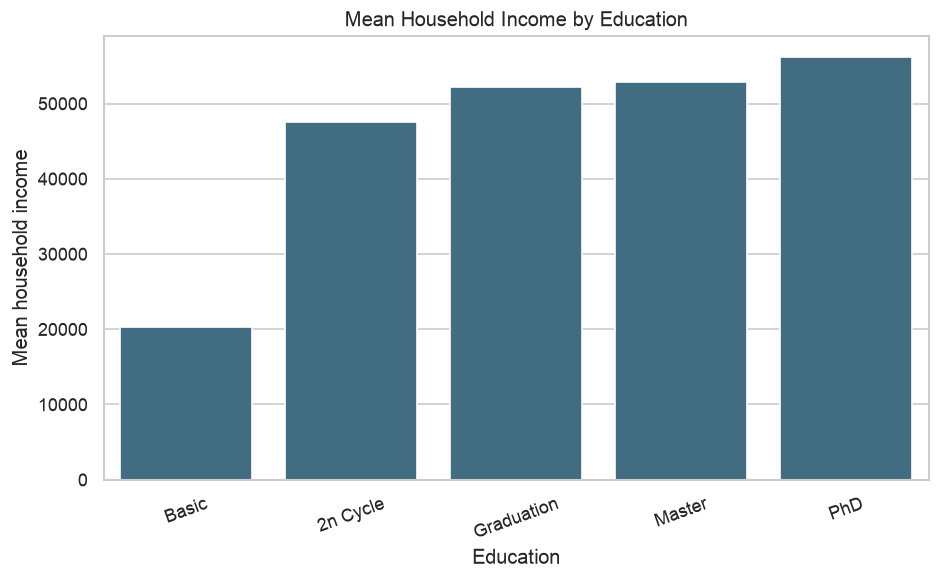

In [5]:
education_order = ['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']
income_by_education = (
    analysis.groupby('Education', observed=True)['Income']
    .mean()
    .reindex(education_order)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=income_by_education.index, y=income_by_education.values, color='#376f8c', ax=ax)
ax.set_title('Mean Household Income by Education')
ax.set_xlabel('Education')
ax.set_ylabel('Mean household income')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(IMAGE_DIR / 'mean_income_by_education.png', bbox_inches='tight')
plt.show()

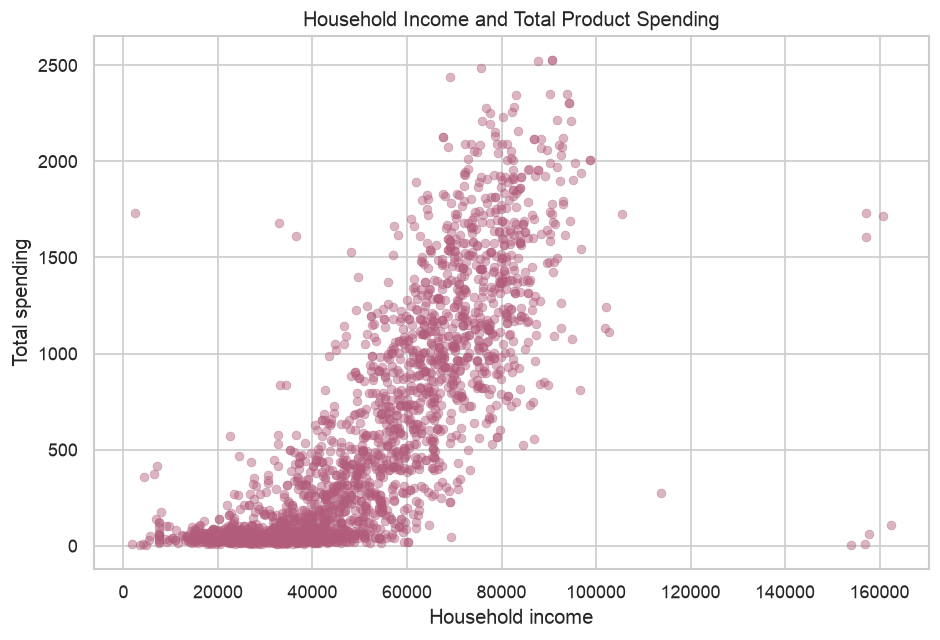

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.scatterplot(data=analysis, x='Income', y='Spending', alpha=0.45, s=28, color='#b15c7b', edgecolor=None, ax=ax)
ax.set_title('Household Income and Total Product Spending')
ax.set_xlabel('Household income')
ax.set_ylabel('Total spending')
fig.tight_layout()
fig.savefig(IMAGE_DIR / 'income_and_spending.png', bbox_inches='tight')
plt.show()

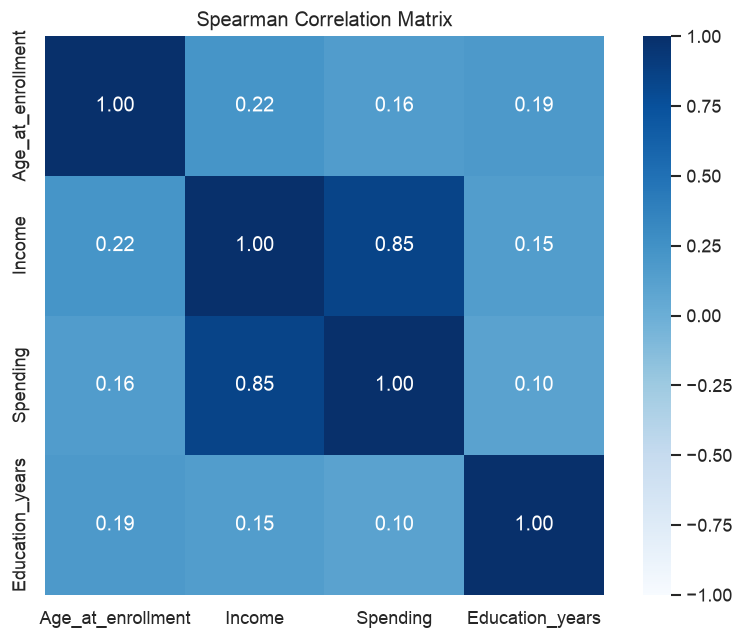

In [7]:
numeric_fields = ['Age_at_enrollment', 'Income', 'Spending', 'Education_years']
correlation = analysis[numeric_fields].corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(correlation, cmap='Blues', vmin=-1, vmax=1, center=0, annot=True, fmt='.2f', square=True, ax=ax)
ax.set_title('Spearman Correlation Matrix')
fig.tight_layout()
fig.savefig(IMAGE_DIR / 'spearman_correlation_matrix.png', bbox_inches='tight')
plt.show()

## Distribution check

Shapiro–Wilk tests are used as a distribution check. Since the variables tested here have p-values below 0.05, the following comparisons use non-parametric tests.

In [8]:
normality_rows = []
for column in ['Age_at_enrollment', 'Income', 'Spending', 'Education_years']:
    statistic, p_value = stats.shapiro(analysis[column])
    normality_rows.append({
        'variable': column,
        'statistic': statistic,
        'p_value': p_value,
        'normal_at_0_05': p_value > ALPHA,
    })
normality_results = pd.DataFrame(normality_rows)
display(normality_results.round({'statistic': 3, 'p_value': 6}))

,variable,statistic,p_value,normal_at_0_05
0,Age_at_enrollment,0.976,0.0,False
1,Income,0.976,0.0,False
2,Spending,0.865,0.0,False
3,Education_years,0.833,0.0,False


## Test 1: PhD and Master's income distributions

**Null hypothesis:** the two groups have equal income distributions.  
**Alternative hypothesis:** the income distributions differ.

In [9]:
phd_income = analysis.loc[analysis['Education'].eq('PhD'), 'Income']
master_income = analysis.loc[analysis['Education'].eq('Master'), 'Income']
mann_whitney_u, mann_whitney_p = stats.mannwhitneyu(
    phd_income, master_income, alternative='two-sided'
)

income_test = pd.DataFrame({
    'PhD sample size': [len(phd_income)],
    "Master's sample size": [len(master_income)],
    'PhD median income': [phd_income.median()],
    "Master's median income": [master_income.median()],
    'Mann–Whitney U': [mann_whitney_u],
    'p_value': [mann_whitney_p],
    'decision_at_0_05': ['Reject the null hypothesis' if mann_whitney_p <= ALPHA else 'Fail to reject the null hypothesis'],
})
display(income_test.round({
    'PhD median income': 0, "Master's median income": 0,
    'Mann–Whitney U': 1, 'p_value': 6,
}))

,PhD sample size,Master's sample size,PhD median income,Master's median income,Mann–Whitney U,p_value,decision_at_0_05
0,486,370,55212.0,50943.0,97800.5,0.027686,Reject the null hypothesis


## Test 2: income and spending

**Null hypothesis:** income and spending have no monotonic association.  
**Alternative hypothesis:** income and spending have a monotonic association.

In [10]:
spearman_rho, spearman_p = stats.spearmanr(analysis['Income'], analysis['Spending'])
correlation_test = pd.DataFrame({
    "Spearman's rho": [spearman_rho],
    'p_value': [spearman_p],
    'decision_at_0_05': ['Reject the null hypothesis' if spearman_p <= ALPHA else 'Fail to reject the null hypothesis'],
})
display(correlation_test.round({"Spearman's rho": 4, 'p_value': 6}))

,Spearman's rho,p_value,decision_at_0_05
0,0.8466,0.0,Reject the null hypothesis


## Test 3: education and marital-status group

**Null hypothesis:** education and the simplified marital-status group are independent.  
**Alternative hypothesis:** the variables are associated.

In [11]:
education_marital_table = pd.crosstab(analysis['Education'], analysis['Marital_Situation'])
chi_square, chi_p_value, degrees_of_freedom, expected = stats.chi2_contingency(education_marital_table)
display(education_marital_table)

chi_square_test = pd.DataFrame({
    'chi_square': [chi_square],
    'degrees_of_freedom': [degrees_of_freedom],
    'p_value': [chi_p_value],
    'decision_at_0_05': ['Reject the null hypothesis' if chi_p_value <= ALPHA else 'Fail to reject the null hypothesis'],
})
display(chi_square_test.round({'chi_square': 3, 'p_value': 6}))

Marital_Situation,Alone,In couple
Education,,
2n Cycle,65,138
Basic,20,34
Graduation,408,718
Master,126,244
PhD,177,309


,chi_square,degrees_of_freedom,p_value,decision_at_0_05
0,1.908,4,0.752606,Fail to reject the null hypothesis


## Takeaways

- The income–spending relationship is strongly positive in rank terms, but this is an association rather than evidence of causation.
- The PhD and Master's groups differ in household-income distribution in this sample. The Mann–Whitney result compares distributions; it does not prove an education effect.
- There is no statistical evidence here of an association between education and the simplified marital-status group.
- The dataset includes three implausibly old ages at enrolment. They are retained for reproducibility but should be checked against source records before use in a customer-facing or operational analysis.